In [1]:
# %%
import scanpy as sc
from matplotlib import pyplot as plt
from pandas import get_dummies
from tensorflow_probability import math as tm
tfk = tm.psd_kernels

2026-04-03 13:13:33.227001: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0


In [2]:
import tensorflow as tf
import tensorflow as tf
import tensorflow_probability as tfp
print(tf.__version__)        # нужно 2.5.0
print(tfp.__version__)       # нужно 0.13.0

2.5.0
0.13.0


In [3]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"   # например, хотим использовать только вторую GPU

import tensorflow as tf
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


2026-04-03 13:13:34.330879: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcuda.so.1
2026-04-03 13:13:34.392778: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:81:00.0 name: NVIDIA L40S computeCapability: 8.9
coreClock: 2.52GHz coreCount: 142 deviceMemorySize: 44.40GiB deviceMemoryBandwidth: 804.75GiB/s
2026-04-03 13:13:34.392822: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2026-04-03 13:13:34.396429: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublas.so.11
2026-04-03 13:13:34.396478: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcublasLt.so.11
2026-04-03 13:13:34.397816: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcufft.so.10
20

In [4]:
#!pip install dill

In [5]:
from models import sf
from utils import misc,preprocess,training,postprocess,visualize
import pandas as pd
import scanpy as sc

In [6]:
path_to_all_selected_genes ="200_intersection_genes.csv"

In [7]:
selected_genes = pd.read_csv(path_to_all_selected_genes)

In [8]:
selected_genes

,real_gene_name
0,FBXL7
1,SVIL
2,DENND1B
3,ADCY8
4,RIT2
...,...
195,PDS5A
196,TMEM117
197,HERC4
198,IL6ST


In [9]:
# id_slice ='T1089_MT66_P0'
# id_slice ='T1090_MT65_P0'
id_slice ='T1091_MT64_P32'
# id_slice ='T1092_MT63_P32'
# id_slice ='T1098_MT69_3M'
# id_slice ='T1099_MT67_7M'

In [10]:
# slice_path = f'../selected_slices/{id_slice}_Visual_Sub-CTX_b100_filtered.h5ad'
slice_path = f'../selected_slices/{id_slice}_Visual_Sub-CTX_V12_b100_filtered.h5ad'

In [11]:
#%% Data loading
ad = sc.read_h5ad(slice_path)
X = ad.obsm["spatial"]

In [12]:


# список нужных генов
genes_keep = selected_genes["real_gene_name"].astype(str).tolist()

# убедиться, что в ad.var есть real_gene_name
ad.var["real_gene_name"] = ad.var["real_gene_name"].astype(str)

# оставить только те гены, которые есть и в ad, и в selected_genes
genes_present = [g for g in genes_keep if g in set(ad.var["real_gene_name"])]

# индекс по имени гена
idx = ad.var.reset_index().groupby("real_gene_name").head(1).set_index("real_gene_name").loc[genes_present]["index"]

# подмножество AnnData
ad = ad[:, idx].copy()

print(ad)

AnnData object with n_obs × n_vars = 12761 × 200
    obs: 'pct_counts_mt', 'orig.ident', 'x', 'y'
    var: 'real_gene_name', 'n_cells', 'n_counts', 'mean_umi'
    uns: 'bin_size', 'bin_type', 'key_record', 'merged', 'resolution', 'sn'
    obsm: 'spatial'


In [13]:
ad.var.real_gene_name

FBXL7        FBXL7
SVIL          SVIL
DENND1B    DENND1B
ADCY8        ADCY8
RIT2          RIT2
            ...   
PDS5A        PDS5A
TMEM117    TMEM117
HERC4        HERC4
IL6ST        IL6ST
GPR75        GPR75
Name: real_gene_name, Length: 200, dtype: object

In [14]:
# sc.pp.calculate_qc_metrics(ad, inplace=True)

In [15]:
# sc.pp.filter_cells(ad, min_counts=100)
# sc.pp.filter_genes(ad, min_cells=1)

In [16]:
# sc.pp.normalize_total(ad, inplace=True, layers=None, key_added="sizefactor")
# sc.pp.log1p(ad)

In [17]:
#raw count data for NSF
D,Dval = preprocess.anndata_to_train_val(ad, layer=None, train_frac=0.8,
                                         flip_yaxis=False)

In [18]:
D["Y"].shape

(10209, 200)

In [19]:
D["X"].shape

(10209, 2)

In [20]:


Ntr,J = D["Y"].shape
Xtr = D["X"]
ad = ad[:Ntr,:]
#convert to tensorflow objects
Dtf = preprocess.prepare_datasets_tf(D,Dval=Dval)

2026-04-03 13:13:40.769418: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-03 13:13:40.789076: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1733] Found device 0 with properties: 
pciBusID: 0000:81:00.0 name: NVIDIA L40S computeCapability: 8.9
coreClock: 2.52GHz coreCount: 142 deviceMemorySize: 44.40GiB deviceMemoryBandwidth: 804.75GiB/s
2026-04-03 13:13:40.792886: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1871] Adding visible gpu devices: 0
2026-04-03 13:13:40.792972: I tensorflow/stream_executor/platform/default/dso_loader.cc:53] Successfully opened dynamic library libcudart.so.11.0
2026-04-03 13:13:41.467396: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1258] Device interconnect StreamExecutor

In [21]:
# #%% Heatmap of true values
# hmkw1 = {"figsize":(8,1.9), "bgcol":"lightgray", "subplot_space":0.1, "marker":"s",
#         "s":2.9}
# Ftrue = ad.obsm["spfac"]
# fig,axes=visualize.multiheatmap(Xtr, Ftrue, (1,4), cmap="Blues", **hmkw1)

In [22]:
#%% Initialize inducing points
L = 10 #number of components
Z = misc.kmeans_inducing_pts(Xtr, 2000)
M = Z.shape[0] #number of inducing points
ker = tfk.MaternThreeHalves

In [23]:
print(type(ker))
print(ker)

<class 'abc.ABCMeta'>
<class 'tensorflow_probability.python.math.psd_kernels.matern.MaternThreeHalves'>


In [24]:
print("J =", J)
print("L =", L)
print("Z shape =", Z.shape)

J = 200
L = 10
Z shape = (2000, 2)


In [25]:
D["Y"].shape

(10209, 200)

In [26]:
Z.shape

(2000, 2)

In [27]:
from matplotlib import pyplot as plt

In [28]:
print(type(ker))
print(ker)

<class 'abc.ABCMeta'>
<class 'tensorflow_probability.python.math.psd_kernels.matern.MaternThreeHalves'>


In [29]:
Xtr.shape

(10209, 2)

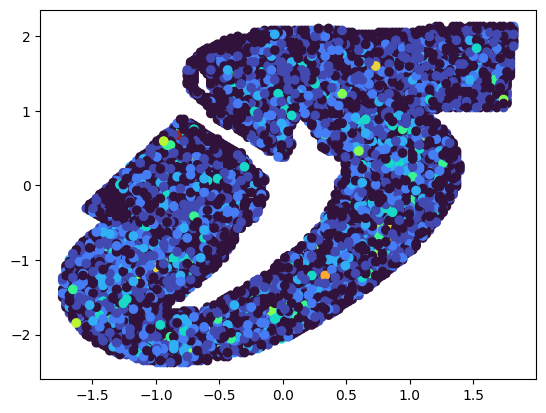

In [30]:
plt.scatter(Xtr[:,0],Xtr[:,1],c=D["Y"][:,2],cmap="turbo")

In [31]:
Xtr.shape

(10209, 2)

In [32]:
D["Y"]

array([[0., 0., 0., ..., 2., 0., 2.],
       [0., 2., 1., ..., 0., 2., 1.],
       [2., 0., 7., ..., 1., 2., 1.],
       ...,
       [4., 0., 2., ..., 1., 1., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 1., ..., 3., 2., 1.]], dtype=float32)

In [33]:
pp = "res_200/{}/NSF{}_{}_M{}".format(id_slice, id_slice,L,ker.__name__, M)

In [34]:
import os

if not os.path.exists("res_200/{}/".format(id_slice)):
    os.mkdir("res_200/{}/".format(id_slice))

In [35]:
len(Dtf)

3

2026-04-03 13:14:07.018316: W tensorflow/python/util/util.cc:348] Sets are not currently considered sequences, but this may change in the future, so consider avoiding using them.


Temporary checkpoint directory: /tmp/tmppt7gen42
Instructions for updating:
The `interpolate_nondiscrete` flag is deprecated; instead use `force_probs_to_zero_outside_support` (with the opposite sense).


2026-04-03 13:14:13.501219: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:176] None of the MLIR Optimization Passes are enabled (registered 2)
2026-04-03 13:14:13.547842: I tensorflow/core/platform/profile_utils/cpu_utils.cc:114] CPU Frequency: 2445555000 Hz


0010 train: 2.748e+02, val: 2.795e+02
0020 train: 2.737e+02, val: 2.787e+02
0030 train: 2.729e+02, val: 2.780e+02
0040 train: 2.725e+02, val: 2.776e+02
0050 train: 2.720e+02, val: 2.775e+02
0060 train: 2.718e+02, val: 2.774e+02
0070 train: 2.716e+02, val: 2.773e+02
0080 train: 2.716e+02, val: 2.773e+02
0090 train: 2.714e+02, val: 2.772e+02
0100 train: 2.713e+02, val: 2.772e+02
0110 train: 2.713e+02, val: 2.773e+02, chg: 7.56e-05
0120 train: 2.712e+02, val: 2.772e+02, chg: 5.33e-05
0130 train: 2.711e+02, val: 2.772e+02, chg: 3.71e-05
0140 train: 2.711e+02, val: 2.772e+02, chg: 2.56e-05
0140 training complete, converged.
CPU times: user 11h 52min 47s, sys: 3h 56min 11s, total: 15h 48min 58s
Wall time: 12min 30s


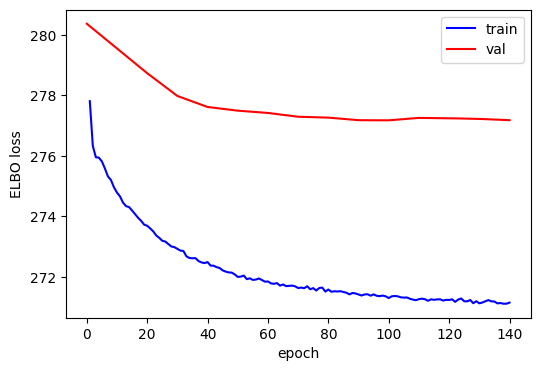

In [36]:
with tf.device("/CPU:0"):
    fit = sf.SpatialFactorization(J, L, Z, lik="poi", psd_kernel=ker,
                                      nugget=1e-5, length_scale=0.1, disp="default",
                                      nonneg=True, isotropic=True,
                                      feature_means=None)
    fit.init_loadings(D["Y"], X=Xtr, sz=D["sz"], shrinkage=0.3)
    tro = training.ModelTrainer(fit, lr=0.01, pickle_path=pp, max_to_keep=3)
    %time tro.train_model(*Dtf, S=3, verbose=True, num_epochs=10000, ckpt_freq=50, kernel_hp_update_freq=10,status_freq=10, span=100, tol=5e-5, pickle_freq=10, lr_reduce=0.5, maxtry=10)
    visualize.plot_loss(tro.loss)

In [37]:
from models import sf
from utils import misc,preprocess,training,postprocess,visualize
import numpy as np

In [38]:
with tf.device("/CPU:0"):    
    insfh = postprocess.interpret_nsf(fit,Xtr,S=10,lda_mode=False)
    misc.pickle_to_file(insfh,f"res_200/{id_slice}/insfh_{id_slice}_L10_M3000_spde.pickle")
    tgnames = [str(i) for i in range(1,L+1)]


In [39]:
hmkw = {"figsize":(15,6),"s":0.4,"marker":".","subplot_space":0,
        "spinecolor":"white"}

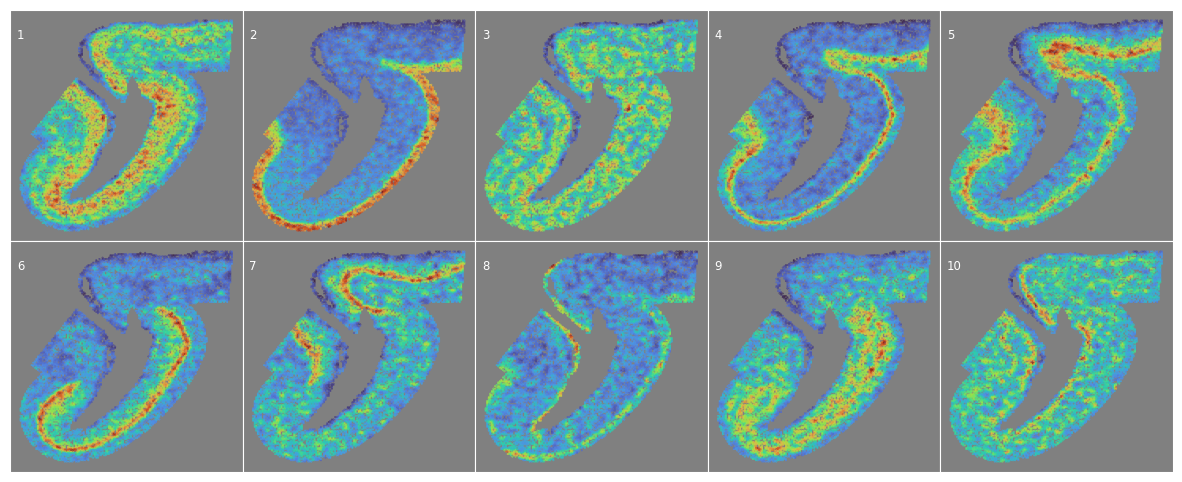

In [40]:
with tf.device("/CPU:0"): 
    fig,axes=visualize.multiheatmap(Xtr, np.sqrt(insfh["factors"]),
                                    (2,5), **hmkw)
    visualize.set_titles(fig, tgnames, x=0.03, y=.88, fontsize="small", c="white",
                         ha="left", va="top")
    fig.savefig(f"res_200/{id_slice}/{id_slice}_heatmap_nsf10_spde_spat.png",
                bbox_inches='tight', dpi=300)

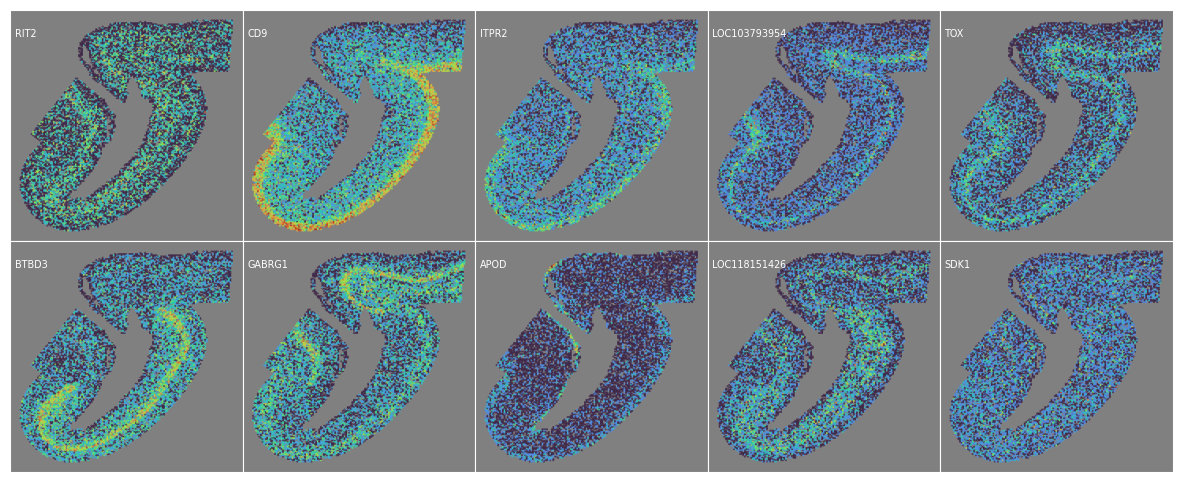

In [41]:
#%% Top genes for each latent dimension
with tf.device("/CPU:0"): 
    W = insfh["loadings"]#*insf["totals"][:,None]
    W[np.isnan(W)] = 0.0
    topgenes = W.argmax(axis=0).tolist()
    tgnames = ad.var.index[topgenes]
    Ytg = D["Y"][:,topgenes]/D["sz"]
    fig,axes=visualize.multiheatmap(Xtr, np.sqrt(Ytg), (2,5), **hmkw)
    visualize.set_titles(fig, tgnames, x=0.02, y=.88, fontsize="x-small", c="white",
                         ha="left", va="top")
    fig.savefig(f"res_200/{id_slice}/{id_slice}_heatmap_nsfh20_spde_spat_genes.png",
                bbox_inches='tight', dpi=300)

In [42]:
import pandas as pd

In [43]:
#save loadings to disk for further interpretation
with tf.device("/CPU:0"): 
    # W = W*insfh["totals"][:,None]
    Wdf=pd.DataFrame(W, index=ad.var.index, columns=range(1,L+1))
    Wdf.to_csv(f"res_200/{id_slice}/{id_slice}_nsfh20_spde_loadings.csv")

In [44]:
Wdf[1].sort_values()

SDK1       0.000000
PHACTR2    0.000000
TLE4       0.000000
PTCHD4     0.000000
GABRG1     0.000000
             ...   
UBASH3B    0.324179
PLCB4      0.337011
PLXDC2     0.337973
TRERF1     0.363579
RIT2       0.497521
Name: 1, Length: 200, dtype: float32